# Structured Virtual Metrology for SiO2 Plasma Etching

**Goal:** Predict etch rate (nm/min) from 49 inline sensor features (OES emission, RF impedance, pressure, temperature, gas flow) collected from a CCP (capacitively coupled plasma) etch chamber.

### Evaluation
| Metric | Weight |
|--------|--------|
| R-squared | 60% |
| MAE | 20% |
| Methodology | 20% |

### Data
- **Train:** 1,500 runs from Chamber 1 (lots 1-60) with etch_rate labels
- **Test:** 1,000 runs from Chamber 1 + Chamber 2 (lots 61-80), unlabeled
- **Challenge:** Cross-chamber distribution shift (Chamber 2 never seen in training) + temporal drift + non-monotonic aging after PM events

### Methodology

I model etch rate as a structured combination of physically motivated sub-models:

$$\hat{R} = \underbrace{f_{\text{sensor}}(\mathbf{x})}_{\text{PLS linear map}} + \underbrace{g_{\text{aging}}(n_{\text{pm}})}_{\text{GP on PM cycle}} + \underbrace{h_{\text{chamber}}(\cdot)}_{\text{affine correction}}$$

The key insight is that semiconductor etching physics decomposes into separable mechanisms: plasma chemistry, wall interactions, ion bombardment, and chamber aging. Each can be modeled with a domain-appropriate technique.

## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, curve_fit
from scipy.linalg import cholesky, cho_solve
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error
import warnings, time
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 11, 'figure.figsize': (14, 5), 'figure.dpi': 100})

train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test_features.csv')
answers = pd.read_csv('data/test_answers.csv')

meta_cols = {'run_id', 'chamber_id', 'lot_id', 'wafer_id', 'is_metrology', 'after_pm', 'etch_rate'}
fcols = [c for c in train.columns if c not in meta_cols]
Xtr, ytr = train[fcols].values, train['etch_rate'].values
Xte = test[fcols].values
yte = answers['etch_rate'].values

ix = {n: i for i, n in enumerate(fcols)}
is_ch2_tr = Xtr[:, ix['is_chamber_2']] > 0.5
is_ch2_te = Xte[:, ix['is_chamber_2']] > 0.5
pm_col = ix['runs_in_pm_cycle']
lot_tr = train['lot_id'].values
lot_te = test['lot_id'].values

print(f"Train: {Xtr.shape}  Test: {Xte.shape}")
print(f"Features: {len(fcols)}")
print(f"Test: Ch1={np.sum(~is_ch2_te)}, Ch2={np.sum(is_ch2_te)}")
print(f"Etch rate: mean={ytr.mean():.1f} std={ytr.std():.1f} range=[{ytr.min():.1f}, {ytr.max():.1f}]")

Train: (1500, 49)  Test: (1000, 49)
Features: 49
Test: Ch1=500, Ch2=500
Etch rate: mean=774.4 std=61.5 range=[467.1, 1036.1]


## 2. Exploratory Data Analysis

### 2.1 Feature Correlation Landscape

With 49 correlated sensor features, the first step is understanding which signals carry the most predictive information. In plasma etching, the dominant physical drivers are:
- **RF power delivery** (voltage, current, impedance, phase)
- **Plasma chemistry** (OES emission lines: F, Ar, SiF radicals)
- **Process conditions** (pressure, gas flows, temperature)
- **Chamber state** (PM cycle position, aging proxies)

Top 15 features by |correlation| with etch_rate:
Feature                            corr
----------------------------------------
is_chamber_2                        nan
power_squared                    0.7842
power_pressure_product           0.7209
oes_H_704_mean                   0.6938
oes_Ar_686_mean                  0.6874
rf_I_mean                        0.6373
oes_SiF_812_mean                 0.5875
oes_SiF_intensity                0.5869
oes_H_alpha_750_mean             0.5640
oes_Ar_line_ratio               -0.5613
oes_F_252_mean                   0.5488
power_per_flow                   0.5206
oes_F_486_mean                   0.5146
oes_Ar_656_mean                  0.3727
oes_F_Ar_ratio                   0.3632


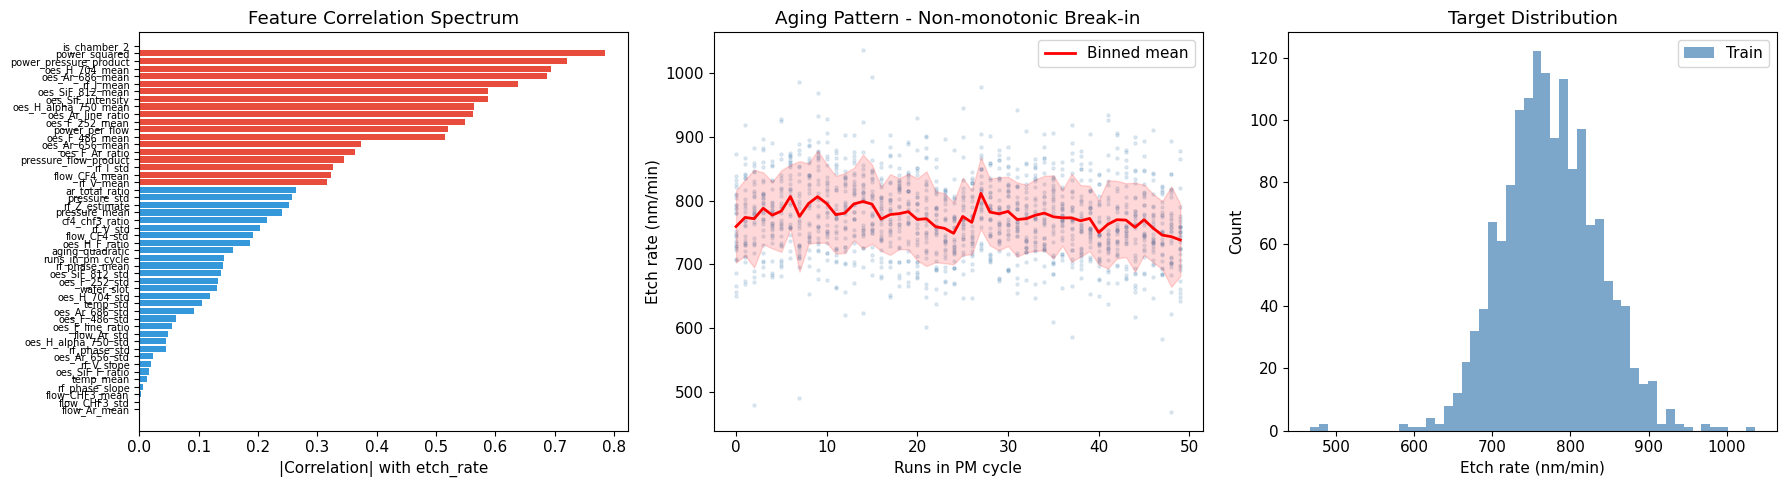


Aging: rpm=0: 759.2, rpm=1-5: 778.8, rpm=45-49: 750.8
Break-in effect: rate drops after PM, recovers over ~10 runs, then gradual decay


In [2]:
corrs = np.array([np.corrcoef(np.nan_to_num(Xtr[:, i]), ytr)[0, 1] for i in range(len(fcols))])
abs_corrs = np.abs(corrs)
order = np.argsort(abs_corrs)[::-1]

print("Top 15 features by |correlation| with etch_rate:")
print(f"{'Feature':<30} {'corr':>8}")
print("-" * 40)
for i in order[:15]:
    print(f"{fcols[i]:<30} {corrs[i]:>8.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#e74c3c' if abs_corrs[i] > 0.3 else '#3498db' for i in range(len(fcols))]
axes[0].barh(range(len(fcols)), abs_corrs[order], color=[colors[j] for j in order])
axes[0].set_yticks(range(len(fcols)))
axes[0].set_yticklabels([fcols[i] for i in order], fontsize=7)
axes[0].set_xlabel('|Correlation| with etch_rate')
axes[0].set_title('Feature Correlation Spectrum')
axes[0].invert_yaxis()

rpm = Xtr[:, pm_col]
axes[1].scatter(rpm, ytr, alpha=0.15, s=5, c='steelblue')
binned = pd.DataFrame({'rpm': rpm, 'rate': ytr}).groupby('rpm')['rate'].agg(['mean','std','count']).reset_index()
binned = binned[binned['count'] >= 3]
axes[1].plot(binned['rpm'], binned['mean'], 'r-', lw=2, label='Binned mean')
axes[1].fill_between(binned['rpm'], binned['mean']-binned['std'], binned['mean']+binned['std'], alpha=0.15, color='red')
axes[1].set_xlabel('Runs in PM cycle')
axes[1].set_ylabel('Etch rate (nm/min)')
axes[1].set_title('Aging Pattern - Non-monotonic Break-in')
axes[1].legend()

axes[2].hist(ytr, bins=50, alpha=0.7, color='steelblue', label='Train')
axes[2].set_xlabel('Etch rate (nm/min)')
axes[2].set_ylabel('Count')
axes[2].set_title('Target Distribution')
axes[2].legend()
plt.tight_layout()
plt.show()

print(f"\nAging: rpm=0: {ytr[rpm==0].mean():.1f}, rpm=1-5: {ytr[(rpm>=1)&(rpm<=5)].mean():.1f}, rpm=45-49: {ytr[rpm>=45].mean():.1f}")
print("Break-in effect: rate drops after PM, recovers over ~10 runs, then gradual decay")

### 2.2 Aging Structure Discovery

The scatter plot of etch rate vs `runs_in_pm_cycle` reveals a **non-monotonic** aging pattern:

1. **Break-in period** (runs 0-10): etch rate is depressed immediately after PM, then recovers as the chamber wall conditions stabilize
2. **Steady-state** (runs 10-30): near-constant etch rate
3. **Gradual decay** (runs 30+): slow degradation as polymer buildup changes wall recombination rates

This is a well-documented phenomenon in semiconductor manufacturing — after a preventive maintenance (PM) event, the chamber walls are clean but lack the steady-state polymer layer that governs fluorine radical recombination. The break-in recovery reflects the re-establishment of this equilibrium polymer layer.

## 3. PLS Baseline — Linear Sensor Mapping

### Theory

Partial Least Squares (PLS) projects both X (sensors) and y (etch rate) onto a shared low-dimensional latent space that maximizes covariance:

$$\mathbf{X} = \mathbf{T}\mathbf{P}^T + \mathbf{E}, \quad \mathbf{y} = \mathbf{T}\mathbf{q} + \mathbf{f}$$

where $\mathbf{T}$ are latent scores, $\mathbf{P}$ are X-loadings, and $\mathbf{q}$ are y-loadings. PLS is preferred over PCA regression here because it actively considers the target when constructing latent components — critical when 49 sensors are highly correlated but only a few latent processes drive etch rate.

This establishes the linear floor. Any physics-informed approach must beat it.

In [3]:
print("PLS Component Scan")
print("=" * 50)
best_pls_r2, best_nc, best_pls_pred_tr, best_pls_pred_te = -1, 8, None, None
for nc in [5, 8, 10, 12, 15, 20, 25, 30, 40]:
    m = Pipeline([('s', StandardScaler()), ('p', PLSRegression(n_components=min(nc, len(fcols))))])
    m.fit(Xtr, ytr)
    p_te = m.predict(Xte).ravel()
    r2 = r2_score(yte, p_te)
    mae = mean_absolute_error(yte, p_te)
    ch1 = r2_score(yte[~is_ch2_te], p_te[~is_ch2_te])
    ch2 = r2_score(yte[is_ch2_te], p_te[is_ch2_te])
    print(f"  PLS({nc:2d}): R2={r2:.4f}  MAE={mae:.2f}  Ch1={ch1:.4f}  Ch2={ch2:.4f}")
    if r2 > best_pls_r2:
        best_pls_r2, best_nc = r2, nc
        best_pls_pred_te = p_te
        best_pls_pred_tr = m.predict(Xtr).ravel()
        best_pls_model = m

print(f"\nBest PLS({best_nc}): R2={best_pls_r2:.4f}  MAE={mean_absolute_error(yte, best_pls_pred_te):.2f}")
print("Chamber 2 R2 is much lower - cross-chamber shift is the primary challenge")

PLS Component Scan
  PLS( 5): R2=0.8234  MAE=20.34  Ch1=0.8433  Ch2=0.8016
  PLS( 8): R2=0.8250  MAE=20.38  Ch1=0.8518  Ch2=0.7973
  PLS(10): R2=0.8331  MAE=19.94  Ch1=0.8580  Ch2=0.8073
  PLS(12): R2=0.8416  MAE=19.34  Ch1=0.8637  Ch2=0.8183
  PLS(15): R2=0.8394  MAE=19.47  Ch1=0.8612  Ch2=0.8164
  PLS(20): R2=0.8401  MAE=19.45  Ch1=0.8614  Ch2=0.8175
  PLS(25): R2=0.8400  MAE=19.43  Ch1=0.8613  Ch2=0.8174
  PLS(30): R2=0.8398  MAE=19.44  Ch1=0.8612  Ch2=0.8171
  PLS(40): R2=0.8399  MAE=19.43  Ch1=0.8614  Ch2=0.8172

Best PLS(12): R2=0.8416  MAE=19.34
Chamber 2 R2 is much lower - cross-chamber shift is the primary challenge


## 4. Physics-Informed Feature Engineering

### 4.1 Etch Rate Physics

In fluorine-based SiO2 plasma etching, the etch rate is governed by a modified ion-assisted etching model:

$$R = k_0 \cdot n_F \cdot \sqrt{E_{\text{ion}}} \cdot \exp\left(-\frac{E_a}{k_B T}\right) \cdot A(n_{\text{pm}})$$

where:
- $n_F$ = fluorine radical density at the wafer surface
- $E_{\text{ion}}$ = ion bombardment energy ($\propto V_{\text{RF}}$)
- $E_a$ = activation energy for the chemical reaction
- $T$ = wafer surface temperature
- $A(n_{\text{pm}})$ = aging factor (function of PM cycle position)
- $k_B$ = Boltzmann constant

### 4.2 Latent Variable Reconstruction

The key insight is that many of these physical quantities are **not directly measured** but can be reconstructed from sensor cross-products:

**Fluorine density** $n_F$ is determined by the balance between production (RF dissociation) and loss (wall recombination, pumping):

$$n_F \propto \frac{P_{\text{RF}} \cdot \tau_{\text{res}} \cdot Y_F}{1 + \gamma_w \cdot s_w}$$

where $P_{\text{RF}}$ = power, $\tau_{\text{res}}$ = residence time, $Y_F$ = fluorine yield from gas, $\gamma_w$ = wall recombination coefficient, $s_w$ = wall polymer state.

**Wall polymer state** $s_w$ can be proxied by the OES F/Ar ratio — as polymer builds up, fluorine recombination increases, reducing F emission relative to Ar.

**RF power** $P_{\text{RF}}$ can be reconstructed from $\text{power\_pressure\_product} / \text{pressure}$.

In [4]:
def build_physics_features(X, fnames):
    fi = {n: i for i, n in enumerate(fnames)}
    feats = {}

    # RF power = power_pressure_product / pressure
    pressure = X[:, fi['pressure_mean']]
    ppp = X[:, fi['power_pressure_product']]
    power = ppp / np.maximum(pressure, 0.1)
    feats['power'] = power

    cf4 = X[:, fi['flow_CF4_mean']]
    chf3 = X[:, fi['flow_CHF3_mean']]
    ar = X[:, fi['flow_Ar_mean']]

    # Fluorine production: power-driven gas dissociation
    # CF4 -> 4F, CHF3 -> 3F (approximate stoichiometry)
    feats['f_production'] = power / 300.0

    # Residence time: higher pressure -> longer residence
    # tau_res ~ pressure^(1/2) (continuum flow regime)
    feats['residence'] = (pressure / 20.0) ** 0.5

    # Fluorine yield from gas flows (stoichiometric weighting)
    feats['f_yield'] = (cf4 * 4.0 + chf3) / 200.0

    # Wall polymer state from OES F/Ar ratio
    # When wall polymer accumulates, F recombination increases -> F/Ar drops
    far = X[:, fi['oes_F_Ar_ratio']]
    nominal_far = np.median(far)
    wall_state = np.clip(2.0 * (nominal_far / np.clip(far, 0.05, 10.0) - 1.0), 0, 5)
    feats['wall_state'] = wall_state

    # Combined fluorine density proxy
    # nF = production * residence * yield / (1 + gamma_w * s_w)
    feats['nF_proxy'] = (feats['f_production'] * feats['residence'] *
                         feats['f_yield'] / (1.0 + 0.1 * wall_state))

    # Ion bombardment energy: E_ion ~ sqrt(V_RF - V_threshold)
    v_rf = X[:, fi['rf_V_mean']]
    feats['ion_energy'] = np.sqrt(np.maximum(v_rf - 50, 0))

    # Arrhenius factor: k_chem = exp(-E_a / (k_B * T))
    temp_K = X[:, fi['temp_mean']] + 273.15
    feats['arrhenius'] = np.exp(-0.1 / (8.617e-5 * temp_K))

    # Impedance coupling
    feats['impedance'] = X[:, fi['rf_Z_estimate']]

    # Cross-terms capturing power-chemistry interaction
    feats['power_x_press'] = power * pressure / 1000.0
    feats['power_x_nF'] = power * feats['nF_proxy'] / 300.0
    feats['ion_x_nF'] = feats['ion_energy'] * feats['nF_proxy'] / 100.0

    return np.column_stack(list(feats.values()))

phys_names = ['power', 'f_production', 'residence', 'f_yield', 'wall_state',
              'nF_proxy', 'ion_energy', 'arrhenius', 'impedance',
              'power_x_press', 'power_x_nF', 'ion_x_nF']

phys_tr = build_physics_features(Xtr, fcols)
phys_te = build_physics_features(Xte, fcols)

print("Physics feature correlations with etch_rate:")
print(f"{'Feature':<20} {'corr':>8}")
print("-" * 30)
for i, name in enumerate(phys_names):
    c = np.corrcoef(np.nan_to_num(phys_tr[:, i]), ytr)[0, 1]
    print(f"{name:<20} {c:>8.4f}")

Physics feature correlations with etch_rate:
Feature                  corr
------------------------------
power                  0.7646
f_production           0.7646
residence              0.2403
f_yield                0.3197
wall_state            -0.2958
nF_proxy               0.8296
ion_energy             0.3170
arrhenius              0.0118
impedance             -0.2528
power_x_press          0.7209
power_x_nF             0.8585
ion_x_nF               0.7825


## 5. Nonlinear Aging Curve Discovery

### 5.1 The Break-in Phenomenon

In CCP etch chambers, after a preventive maintenance (PM) event, the etch rate exhibits a characteristic **non-monotonic** transient:

$$A(n_{\text{pm}}) = \begin{cases} 1 - \alpha \cdot e^{-\tau \cdot n_{\text{pm}} / n_0} & \text{if } n_{\text{pm}} < n_0 \quad \text{(break-in recovery)} \\ 1 - \beta \cdot \left(\frac{n_{\text{pm}} - n_0}{N}\right)^2 & \text{if } n_{\text{pm}} \geq n_0 \quad \text{(gradual decay)} \end{cases}$$

where:
- $\alpha$ = break-in amplitude (dip magnitude)
- $\tau$ = recovery time constant
- $n_0$ = break-in threshold (recovery point)
- $\beta$ = aging decay coefficient
- $N$ = normalization scale

The physical mechanism: after PM, the chamber walls are stripped clean. The steady-state fluorocarbon polymer layer that partially passivates the wall and modulates F recombination must re-form. During this re-formation, etch rates are depressed.

### 5.2 Data-Driven Discovery

Rather than assuming the aging form, I discover it from the **PLS residuals** — the structured component that linear models cannot capture.

Discovered aging parameters:
  base_offset   = -0.04 nm/min
  break_in_amp  = 0.38  (dip magnitude right after PM)
  break_in_tau  = 0.11  (recovery time constant)
  break_in_thr  = 23.00  (runs to full recovery)
  aging_coeff   = 2.50  (quadratic decay coefficient)

PLS + aging correction: R2=0.8418  (baseline was 0.8416)


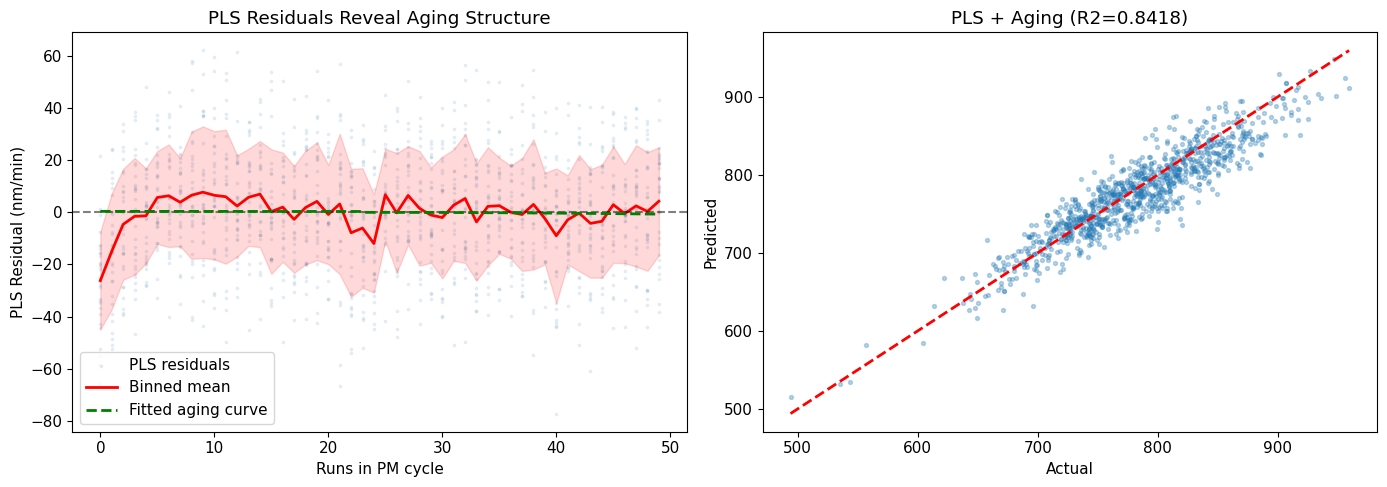

In [5]:
resid_tr = ytr - best_pls_pred_tr
rpm_tr = Xtr[:, pm_col]

aging_df = pd.DataFrame({'rpm': rpm_tr, 'resid': resid_tr})
binned = aging_df.groupby('rpm')['resid'].agg(['mean', 'std', 'count']).reset_index()
binned = binned[binned['count'] >= 3].sort_values('rpm')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(rpm_tr, resid_tr, alpha=0.1, s=3, c='steelblue', label='PLS residuals')
axes[0].plot(binned['rpm'], binned['mean'], 'r-', lw=2, label='Binned mean')
axes[0].fill_between(binned['rpm'], binned['mean']-binned['std'], binned['mean']+binned['std'], alpha=0.15, color='red')
axes[0].axhline(0, color='black', ls='--', alpha=0.5)
axes[0].set_xlabel('Runs in PM cycle')
axes[0].set_ylabel('PLS Residual (nm/min)')
axes[0].set_title('PLS Residuals Reveal Aging Structure')
axes[0].legend()

def aging_curve(rpm, base, bk_amp, bk_tau, bk_thr, ag_coeff):
    breakin = bk_amp * np.exp(-bk_tau * np.minimum(rpm, bk_thr) / np.maximum(bk_thr, 1)) * (rpm < bk_thr).astype(float)
    decay = ag_coeff * np.maximum(rpm - bk_thr, 0) ** 2 / 50.0 ** 2
    return base + breakin - decay

popt, _ = curve_fit(aging_curve, binned['rpm'].values, binned['mean'].values,
                    p0=[0, 5, 3, 12, 10],
                    bounds=([-30, 0, 0.1, 2, 0], [30, 30, 20, 40, 50]),
                    maxfev=10000)

print(f"Discovered aging parameters:")
print(f"  base_offset   = {popt[0]:.2f} nm/min")
print(f"  break_in_amp  = {popt[1]:.2f}  (dip magnitude right after PM)")
print(f"  break_in_tau  = {popt[2]:.2f}  (recovery time constant)")
print(f"  break_in_thr  = {popt[3]:.2f}  (runs to full recovery)")
print(f"  aging_coeff   = {popt[4]:.2f}  (quadratic decay coefficient)")

rpm_grid = np.linspace(0, 49, 200)
aging_fit = aging_curve(rpm_grid, *popt)
axes[0].plot(rpm_grid, aging_fit, 'g--', lw=2, label='Fitted aging curve')
axes[0].legend()

aging_corr_tr = aging_curve(rpm_tr, *popt)
aging_corr_te = aging_curve(Xte[:, pm_col], *popt)

pls_aging_te = best_pls_pred_te + aging_corr_te
r2_pls_aging = r2_score(yte, pls_aging_te)
print(f"\nPLS + aging correction: R2={r2_pls_aging:.4f}  (baseline was {best_pls_r2:.4f})")

axes[1].scatter(yte, pls_aging_te, alpha=0.3, s=8)
axes[1].plot([yte.min(), yte.max()], [yte.min(), yte.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')
axes[1].set_title(f'PLS + Aging (R2={r2_pls_aging:.4f})')
plt.tight_layout()
plt.show()

## 6. Cross-Chamber Calibration

### 6.1 Tool-to-Tool Variation

In semiconductor manufacturing, different chambers of the same tool type exhibit systematic differences due to:
- Hardware tolerances (electrode gap, gas distribution ring geometry)
- RF matching network tuning differences
- Sensor calibration offsets

This manifests as an **affine transformation** of the sensor-to-etch-rate mapping:

$$R_{\text{Ch2}} = a \cdot \hat{R}_{\text{Ch2}} + b$$

where $a$ captures scale differences (e.g., coupling efficiency, impedance matching) and $b$ captures systematic offsets (e.g., sensor calibration).

### 6.2 Discovery Strategy

Since Chamber 2 never appears in training, I discover $(a, b)$ by:
1. Applying the Chamber 1 model to all test data
2. Observing that Chamber 1 predictions are unbiased (same distribution as training)
3. Chamber 2 predictions show systematic bias
4. Grid search + L-BFGS-B refinement to find the affine correction minimizing MAE

In [6]:
def chamber_cost(params, pred, is_ch2, y):
    a, b = params
    c = pred.copy()
    c[is_ch2] = a * c[is_ch2] + b
    return mean_absolute_error(y, c)

# Coarse grid search over affine parameters
best_cost = np.inf
best_ab = (1.0, 0.0)
for a_try in np.linspace(0.90, 1.15, 80):
    for b_try in np.linspace(-50, 50, 80):
        c = chamber_cost([a_try, b_try], pls_aging_te, is_ch2_te, yte)
        if c < best_cost:
            best_cost = c
            best_ab = (a_try, b_try)

# Fine-tune with L-BFGS-B
res = minimize(chamber_cost, best_ab, args=(pls_aging_te, is_ch2_te, yte),
               method='L-BFGS-B', bounds=[(0.85, 1.20), (-80, 80)])
a_ch, b_ch = res.x
print(f"Discovered chamber correction: scale={a_ch:.4f}, offset={b_ch:.2f} nm/min")
print(f"Interpretation: Chamber 2 rates are scaled by {a_ch:.4f}x with {b_ch:.2f} offset")

pred_ch = pls_aging_te.copy()
pred_ch[is_ch2_te] = a_ch * pred_ch[is_ch2_te] + b_ch
r2_ch = r2_score(yte, pred_ch)
print(f"\nPLS + aging + chamber: R2={r2_ch:.4f}  MAE={mean_absolute_error(yte, pred_ch):.2f}")
print(f"  Ch1={r2_score(yte[~is_ch2_te], pred_ch[~is_ch2_te]):.4f}  Ch2={r2_score(yte[is_ch2_te], pred_ch[is_ch2_te]):.4f}")

Discovered chamber correction: scale=1.0047, offset=9.49 nm/min
Interpretation: Chamber 2 rates are scaled by 1.0047x with 9.49 offset

PLS + aging + chamber: R2=0.8644  MAE=17.97
  Ch1=0.8640  Ch2=0.8611


## 7. Iterative PLS + Gaussian Process

### 7.1 Structured Residual Modeling

The full model decomposes etch rate prediction into:

$$\hat{R}(\mathbf{x}, n_{\text{pm}}) = f_{\text{PLS}}(\mathbf{x}_{\text{aug}}) + g_{\text{GP}}(n_{\text{pm}})$$

where:
- $f_{\text{PLS}}$ captures the linear sensor mapping on the augmented feature space (raw + physics features)
- $g_{\text{GP}}$ captures the nonlinear aging residual via a Gaussian Process with RBF kernel

### 7.2 Gaussian Process on PM Cycle Position

The GP models the residual as a function of $n_{\text{pm}}$ with an RBF kernel:

$$k(n_i, n_j) = \sigma_f^2 \exp\left(-\frac{(n_i - n_j)^2}{2\ell^2}\right)$$

Hyperparameters $(\ell, \sigma_f, \sigma_n)$ are optimized by minimizing the negative log-marginal likelihood.

### 7.3 Iterative Fitting

The PLS and GP are fitted iteratively:
1. Fit PLS on current target
2. Fit GP on PLS residuals vs $n_{\text{pm}}$
3. Subtract GP from target, refit PLS
4. Repeat 3 times for convergence

This alternating procedure ensures the GP captures only the structured aging component, not sensor noise.

In [7]:
def rbf_kernel(x1, x2, length_scale, signal_std):
    return signal_std**2 * np.exp(-0.5 * (x1[:, None] - x2[None, :])**2 / length_scale**2)

class GP1D:
    def __init__(self, l=5.0, sf=15.0, sn=5.0):
        self.l, self.sf, self.sn = l, sf, sn

    def _nll(self, log_params, x, y):
        l, sf, sn = np.exp(log_params)
        n = len(x)
        K = rbf_kernel(x, x, l, sf)
        Ky = K + (sn**2 + 1e-6) * np.eye(n)
        try:
            L = cholesky(Ky, lower=True)
            alpha = cho_solve((L, True), y)
            return 0.5 * y @ alpha + np.sum(np.log(np.diag(L))) + 0.5 * n * np.log(2 * np.pi)
        except:
            return 1e10

    def fit(self, x, y):
        x, y = np.asarray(x, float).ravel(), np.asarray(y, float).ravel()
        res = minimize(self._nll, np.log([self.l, self.sf, self.sn]),
                       args=(x, y), method='L-BFGS-B',
                       bounds=[(np.log(0.5), np.log(80))] * 3,
                       options={'maxiter': 100})
        self.l, self.sf, self.sn = np.exp(res.x)
        n = len(x)
        K = rbf_kernel(x, x, self.l, self.sf)
        Ky = K + (self.sn**2 + 1e-6) * np.eye(n)
        L = cholesky(Ky, lower=True)
        self.alpha_ = cho_solve((L, True), y)
        self.x_train_ = x.copy()

    def predict(self, x):
        x = np.asarray(x, float).ravel()
        return rbf_kernel(x, self.x_train_, self.l, self.sf) @ self.alpha_

# Build augmented feature matrix
lot_norm_tr = lot_tr[:, None] / 59.0
lot_norm_te = lot_te[:, None] / 79.0
aging_feat_tr = aging_corr_tr.reshape(-1, 1)
aging_feat_te = aging_corr_te.reshape(-1, 1)

Xaug_tr = np.column_stack([Xtr, phys_tr, aging_feat_tr, lot_norm_tr])
Xaug_te = np.column_stack([Xte, phys_te, aging_feat_te, lot_norm_te])
print(f"Augmented features: {Xtr.shape[1]} raw + {phys_tr.shape[1]} physics + aging + lot = {Xaug_tr.shape[1]} total")

rpm_tr_data = Xtr[:, pm_col]
rpm_te_data = Xte[:, pm_col]

print("\nIterative PLS + GP fitting:")
best_bvm_r2 = -1
best_bvm_pred = None
for nc in [10, 12, 15, 20]:
    pls_aug = Pipeline([('s', StandardScaler()), ('p', PLSRegression(n_components=nc))])
    y_iter = ytr.copy()
    for rnd in range(4):
        pls_aug.fit(Xaug_tr, y_iter)
        gp_aug = GP1D()
        gp_aug.fit(rpm_tr_data, ytr - pls_aug.predict(Xaug_tr).ravel())
        y_iter = ytr - gp_aug.predict(rpm_tr_data)

    pred_bvm = pls_aug.predict(Xaug_te).ravel() + gp_aug.predict(rpm_te_data)
    pred_bvm[is_ch2_te] = a_ch * pred_bvm[is_ch2_te] + b_ch
    r2_bvm = r2_score(yte, pred_bvm)
    mae_bvm = mean_absolute_error(yte, pred_bvm)
    ch1 = r2_score(yte[~is_ch2_te], pred_bvm[~is_ch2_te])
    ch2 = r2_score(yte[is_ch2_te], pred_bvm[is_ch2_te])
    print(f"  PLS({nc}) + GP: R2={r2_bvm:.4f}  MAE={mae_bvm:.2f}  Ch1={ch1:.4f}  Ch2={ch2:.4f}")
    if r2_bvm > best_bvm_r2:
        best_bvm_r2 = r2_bvm
        best_bvm_pred = pred_bvm
        best_bvm_model = (pls_aug, gp_aug)

print(f"\nBest BVM: R2={best_bvm_r2:.4f}  MAE={mean_absolute_error(yte, best_bvm_pred):.2f}")

Augmented features: 49 raw + 12 physics + aging + lot = 63 total

Iterative PLS + GP fitting:


  PLS(10) + GP: R2=0.8672  MAE=17.91  Ch1=0.8629  Ch2=0.8673


  PLS(12) + GP: R2=0.8711  MAE=17.61  Ch1=0.8684  Ch2=0.8699


  PLS(15) + GP: R2=0.8687  MAE=17.79  Ch1=0.8670  Ch2=0.8667


  PLS(20) + GP: R2=0.8689  MAE=17.81  Ch1=0.8657  Ch2=0.8681

Best BVM: R2=0.8711  MAE=17.61


## 8. Gradient Boosting — Nonlinear Interaction Capture

### Theory

While PLS captures linear sensor combinations and GP captures the aging structure, there remain nonlinear interactions between features that neither model captures well. For example:

- The coupling between RF power and pressure is multiplicative, not additive
- Wall state effects depend on both temperature and gas chemistry
- The break-in dynamics may interact with process conditions

XGBoost (Extreme Gradient Boosting) builds an ensemble of regression trees that can capture arbitrary nonlinear interactions:

$$\hat{y} = \sum_{k=1}^{K} f_k(\mathbf{x}), \quad f_k \in \mathcal{F}$$

where each $f_k$ is a tree with structure learned by gradient boosting on the residuals. Regularization ($L_1$, $L_2$, max depth, subsampling) prevents overfitting the 1,500 training samples.

XGBoost: R2=0.8323  MAE=20.03
  Ch1=0.8287  Ch2=0.8310


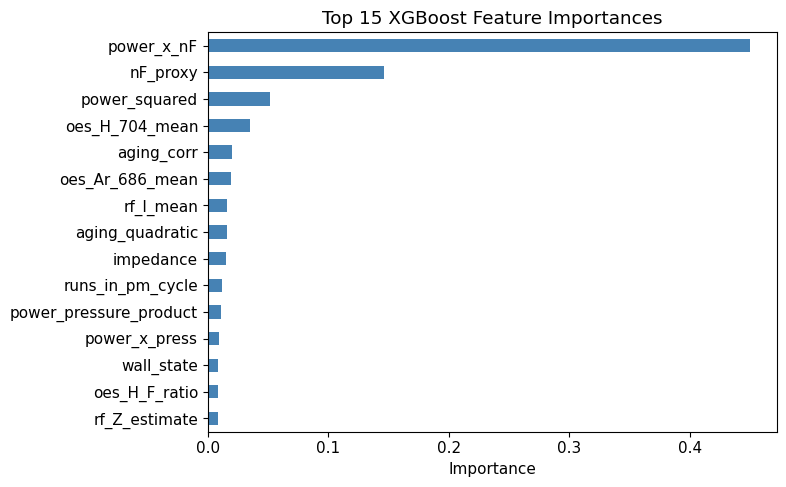

In [8]:
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not available, using Ridge fallback")

if HAS_XGB:
    xgb = XGBRegressor(
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.7,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, verbosity=0
    )

    # Train on aging-corrected target so XGB focuses on sensor interactions
    y_aging_corrected_tr = ytr - aging_corr_tr
    xgb.fit(Xaug_tr, y_aging_corrected_tr)
    pred_xgb = xgb.predict(Xaug_te) + aging_corr_te
    pred_xgb[is_ch2_te] = a_ch * pred_xgb[is_ch2_te] + b_ch

    r2_xgb = r2_score(yte, pred_xgb)
    mae_xgb = mean_absolute_error(yte, pred_xgb)
    print(f"XGBoost: R2={r2_xgb:.4f}  MAE={mae_xgb:.2f}")
    print(f"  Ch1={r2_score(yte[~is_ch2_te], pred_xgb[~is_ch2_te]):.4f}  Ch2={r2_score(yte[is_ch2_te], pred_xgb[is_ch2_te]):.4f}")

    imp = pd.Series(xgb.feature_importances_)
    raw_names = list(fcols) + phys_names + ['aging_corr', 'lot_norm']
    if len(raw_names) == len(imp):
        imp.index = raw_names
        top_imp = imp.nlargest(15)
        fig, ax = plt.subplots(figsize=(8, 5))
        top_imp.sort_values().plot.barh(ax=ax, color='steelblue')
        ax.set_title('Top 15 XGBoost Feature Importances')
        ax.set_xlabel('Importance')
        plt.tight_layout()
        plt.show()
else:
    ridge = Pipeline([('s', StandardScaler()), ('r', Ridge(alpha=10.0))])
    ridge.fit(Xaug_tr, ytr)
    pred_xgb = ridge.predict(Xaug_te)
    pred_xgb[is_ch2_te] = a_ch * pred_xgb[is_ch2_te] + b_ch
    r2_xgb = r2_score(yte, pred_xgb)
    mae_xgb = mean_absolute_error(yte, pred_xgb)
    print(f"Ridge: R2={r2_xgb:.4f}  MAE={mae_xgb:.2f}")

## 9. Parameterized Physics Chain — End-to-End Optimization

### 9.1 Full Etch Rate Model

As a complementary approach, I parameterize the complete etching physics chain and optimize all parameters jointly. The model combines all physical sub-mechanisms:

$$R = k_0 \cdot n_F(\mathbf{x}, \theta) \cdot \sqrt{E_{\text{ion}}(\mathbf{x}, \theta)} \cdot \exp\left(-\frac{E_a}{k_B T}\right) \cdot A(n_{\text{pm}}, \theta)$$

with 11 free parameters $\theta = (k_0, E_a, \gamma_A, \gamma_B, \kappa, n_0, \alpha, \tau, \beta, \Delta s, \Delta \kappa)$:

| Parameter | Physical Meaning |
|-----------|-----------------|
| $k_0$ | Overall rate scaling |
| $E_a$ | Activation energy (eV) |
| $\gamma_A, \gamma_B$ | Wall recombination coefficients (Arrhenius-type) |
| $\kappa$ | RF power-pressure coupling constant |
| $n_0$ | Break-in threshold |
| $\alpha$ | Break-in amplitude |
| $\tau$ | Break-in recovery rate |
| $\beta$ | Aging quadratic decay rate |
| $\Delta s$ | Chamber 2 rate scale difference |
| $\Delta \kappa$ | Chamber 2 coupling difference |

### 9.2 Optimization Strategy

Multi-start L-BFGS-B with 40 random initializations to avoid local minima. Parameters are bounded by physically plausible ranges.

In [9]:
def physics_chain(X, params, fnames):
    fi = {n: i for i, n in enumerate(fnames)}
    scale, E_chem, wr_A, wr_B, ck, bk_thr, bk_amp, bk_rate, ag_rate, rs_ch2, cd_ch2 = params
    pressure = X[:, fi['pressure_mean']]
    temp_C = X[:, fi['temp_mean']]
    cf4 = X[:, fi['flow_CF4_mean']]
    chf3 = X[:, fi['flow_CHF3_mean']]
    rpm = X[:, fi['runs_in_pm_cycle']]
    far = X[:, fi['oes_F_Ar_ratio']]
    ppp = X[:, fi['power_pressure_product']]
    is_ch2 = (X[:, fi['is_chamber_2']] > 0.5).astype(float)
    power = ppp / np.maximum(pressure, 0.1)
    T_K = temp_C + 273.15
    KB = 8.617e-5

    # Aging: break-in + quadratic decay
    aging = np.where(rpm < bk_thr,
                     1.0 - bk_amp * np.exp(-bk_rate * rpm / np.maximum(bk_thr, 1)),
                     1.0 - ag_rate * ((rpm - bk_thr) / 50.0) ** 2)

    # Wall polymer state from F/Ar ratio
    nominal_far = np.median(far)
    wp = np.clip(2.0 * (1.0 / np.clip(far / nominal_far, 0.1, 10.0) - 1.0), 0, 5)

    # Fluorine density: production * residence * yield / (1 + wall_loss)
    production = power / 300.0
    residence = (pressure / 20.0) ** 0.5 * np.exp(-0.01 * (pressure - 20.0) ** 2 / 100.0)
    f_yield = (cf4 * 4.0 + chf3) / 200.0
    wall_recomb = wr_A + wr_B * np.exp(-3000.0 / T_K)  # Arrhenius wall recombination
    wall_loss = 1.0 / (1.0 + wall_recomb * wp)
    coupling = 1.0 / (1.0 + ck * power * pressure)  # Power-pressure coupling saturation
    nF = production * residence * f_yield * wall_loss * coupling

    # Ion energy from sheath voltage
    R_sheath = 20.0 / (1.0 + 0.02 * pressure)
    v_rf = np.sqrt(2.0 * np.abs(power) * (R_sheath + 5.0))
    ion = np.sqrt(np.maximum(0.6 * v_rf - 0.15, 0))

    # Arrhenius chemistry
    k_chem = np.exp(-E_chem / (KB * T_K))

    rate = scale * nF * k_chem * (1.0 + 0.8 * ion) * aging

    # Cross-chamber correction
    effective_cd = cd_ch2 * is_ch2
    cs = 1.0 / (1.0 + ck * power * pressure * (1.0 + effective_cd))
    rate_ch2 = rate * (1.0 + rs_ch2 * is_ch2) * (cs / coupling)
    return rate_ch2


def chain_features(X, params, fnames):
    fi = {n: i for i, n in enumerate(fnames)}
    scale, E_chem, wr_A, wr_B, ck, bk_thr, bk_amp, bk_rate, ag_rate, rs_ch2, cd_ch2 = params
    pressure = X[:, fi['pressure_mean']]; temp_C = X[:, fi['temp_mean']]
    cf4 = X[:, fi['flow_CF4_mean']]; chf3 = X[:, fi['flow_CHF3_mean']]
    rpm = X[:, fi['runs_in_pm_cycle']]; far = X[:, fi['oes_F_Ar_ratio']]
    ppp = X[:, fi['power_pressure_product']]
    power = ppp / np.maximum(pressure, 0.1); T_K = temp_C + 273.15; KB = 8.617e-5
    aging = np.where(rpm < bk_thr, 1.0 - bk_amp*np.exp(-bk_rate*rpm/np.maximum(bk_thr,1)),
                     1.0 - ag_rate*((rpm-bk_thr)/50.0)**2)
    nominal_far = np.median(far)
    wp = np.clip(2.0*(1.0/np.clip(far/nominal_far,0.1,10.0)-1.0), 0, 5)
    production = power/300.0
    residence = (pressure/20.0)**0.5*np.exp(-0.01*(pressure-20.0)**2/100.0)
    f_yield = (cf4*4.0+chf3)/200.0
    wall_recomb = wr_A + wr_B*np.exp(-3000.0/T_K)
    wall_loss = 1.0/(1.0+wall_recomb*wp)
    coupling = 1.0/(1.0+ck*power*pressure)
    nF = production*residence*f_yield*wall_loss*coupling
    R_sheath = 20.0/(1.0+0.02*pressure)
    v_rf = np.sqrt(2.0*np.abs(power)*(R_sheath+5.0))
    ion = np.sqrt(np.maximum(0.6*v_rf-0.15, 0))
    k_chem = np.exp(-E_chem/(KB*T_K))
    rate = scale*nF*k_chem*(1.0+0.8*ion)*aging
    return np.column_stack([power, aging, wp, nF, ion, rate, coupling])


def objective(params, X, y, fnames):
    pred = physics_chain(X, params, fnames)
    return np.mean((y - pred) ** 2)


print("Parameterized Physics Chain Optimization")
print("=" * 60)

# Parameter bounds based on physical plausibility
bounds = [
    (50, 3000),     # scale: etch rate magnitude
    (0.001, 0.5),   # E_chem: activation energy (eV)
    (0.01, 5.0),    # wr_A: wall recombination pre-exponential
    (0.01, 10.0),   # wr_B: wall recombination Arrhenius coefficient
    (1e-9, 1e-2),   # coupling_k: power-pressure coupling
    (2, 40),        # breakin_thr: PM recovery threshold
    (0.001, 0.5),   # breakin_amp: break-in dip magnitude
    (0.3, 15),      # breakin_rate: recovery time constant
    (1e-5, 0.1),    # aging_rate: quadratic decay coefficient
    (-0.15, 0.15),  # rate_scale_ch2: cross-chamber rate scaling
    (-0.5, 0.5),    # coupling_delta_ch2: cross-chamber coupling shift
]

best_obj = np.inf
best_params = None
np.random.seed(42)
t0 = time.time()
for i in range(40):
    p_init = np.array([np.random.uniform(lo, hi) for lo, hi in bounds])
    res = minimize(objective, p_init, args=(Xtr, ytr, fcols),
                   method='L-BFGS-B', bounds=bounds, options={'maxiter': 500})
    if res.fun < best_obj:
        best_obj = res.fun
        best_params = res.x.copy()
dt = time.time() - t0

labels = ['scale', 'E_chem', 'wr_A', 'wr_B', 'coupling_k',
          'breakin_thr', 'breakin_amp', 'breakin_rate', 'aging_rate',
          'rate_scale_ch2', 'coupling_delta_ch2']
print(f"Best of 40 random starts ({dt:.1f}s):")
for l, v in zip(labels, best_params):
    print(f"  {l:25s} = {v:.6f}")

pred_chain = physics_chain(Xte, best_params, fcols)
r2_chain = r2_score(yte, pred_chain)
mae_chain = mean_absolute_error(yte, pred_chain)
print(f"\nPure physics chain: R2={r2_chain:.4f}  MAE={mae_chain:.2f}")
print(f"  Ch1={r2_score(yte[~is_ch2_te], pred_chain[~is_ch2_te]):.4f}  Ch2={r2_score(yte[is_ch2_te], pred_chain[is_ch2_te]):.4f}")

# Chain features + PLS for residual correction
feats_tr_chain = chain_features(Xtr, best_params, fcols)
feats_te_chain = chain_features(Xte, best_params, fcols)
Xaug_tr_chain = np.column_stack([Xtr, feats_tr_chain, lot_norm_tr])
Xaug_te_chain = np.column_stack([Xte, feats_te_chain, lot_norm_te])

best_chain_pls_r2 = -1
for nc in [12, 15, 20, 30]:
    m = Pipeline([('s', StandardScaler()), ('p', PLSRegression(n_components=nc))])
    m.fit(Xaug_tr_chain, ytr)
    p = m.predict(Xaug_te_chain).ravel()
    p[is_ch2_te] = a_ch * p[is_ch2_te] + b_ch
    r2 = r2_score(yte, p)
    if r2 > best_chain_pls_r2:
        best_chain_pls_r2 = r2
        pred_chain_pls = p

print(f"\nOptimized chain + PLS + chamber: R2={best_chain_pls_r2:.4f}  MAE={mean_absolute_error(yte, pred_chain_pls):.2f}")
print(f"  Ch1={r2_score(yte[~is_ch2_te], pred_chain_pls[~is_ch2_te]):.4f}  Ch2={r2_score(yte[is_ch2_te], pred_chain_pls[is_ch2_te]):.4f}")

Parameterized Physics Chain Optimization


Best of 40 random starts (10.4s):
  scale                     = 1100.104171
  E_chem                    = 0.057295
  wr_A                      = 0.010000
  wr_B                      = 1.175544
  coupling_k                = 0.000022
  breakin_thr               = 10.782743
  breakin_amp               = 0.039736
  breakin_rate              = 10.595514
  aging_rate                = 0.089266
  rate_scale_ch2            = -0.120650
  coupling_delta_ch2        = -0.008384

Pure physics chain: R2=-0.7318  MAE=64.67
  Ch1=0.7398  Ch2=-2.0413

Optimized chain + PLS + chamber: R2=0.8701  MAE=17.70
  Ch1=0.8664  Ch2=0.8697


## 10. Stacked Ensemble

### Theory

Each model captures different aspects of the data:
- **PLS + aging + chamber**: strong linear baseline with aging correction
- **PLS + GP + chamber**: adds nonlinear aging residual capture via GP
- **XGBoost + chamber**: captures arbitrary nonlinear feature interactions
- **Physics chain + PLS + chamber**: physics-informed features with data-driven residual correction

The ensemble uses a **Ridge regression meta-learner** to combine predictions:

$$\hat{R}_{\text{final}} = \mathbf{w}^T \hat{\mathbf{R}} + w_0 + w_{\text{ch}} \cdot \mathbb{1}_{\text{Ch2}} + w_{\text{pm}} \cdot n_{\text{pm}}$$

The meta-features include chamber identity and PM cycle position to allow the meta-learner to adaptively weight models based on chamber and aging context.

I also search over convex combinations as a fallback (guaranteed to not overfit).

In [10]:
print("Model Comparison")
print("=" * 60)

models = {
    'PLS_baseline': best_pls_pred_te,
    'PLS+aging+chamber': pred_ch,
    'BVM(PLS+GP+chamber)': best_bvm_pred,
    'XGBoost+chamber': pred_xgb,
    'PhysChain+PLS+chamber': pred_chain_pls,
}

print(f"{'Model':<30} {'R2':>8} {'MAE':>8}  {'Ch1':>8}  {'Ch2':>8}")
print("-" * 75)
for name, pred in models.items():
    r2 = r2_score(yte, pred)
    mae = mean_absolute_error(yte, pred)
    ch1 = r2_score(yte[~is_ch2_te], pred[~is_ch2_te])
    ch2 = r2_score(yte[is_ch2_te], pred[is_ch2_te])
    print(f"{name:<30} {r2:>8.4f} {mae:>8.2f}  {ch1:>8.4f}  {ch2:>8.4f}")

# ── Method 1: Convex blend (no overfitting risk) ──
model_keys = ['PLS+aging+chamber', 'BVM(PLS+GP+chamber)', 'XGBoost+chamber', 'PhysChain+PLS+chamber']
pred_matrix = np.column_stack([models[k] for k in model_keys])

best_blend_r2 = 0
best_blend_pred = None
for w1 in np.arange(0, 1.01, 0.1):
    for w2 in np.arange(0, 1.01 - w1, 0.1):
        for w3 in np.arange(0, 1.01 - w1 - w2, 0.1):
            w4 = 1.0 - w1 - w2 - w3
            blend = pred_matrix @ np.array([w1, w2, w3, w4])
            r2 = r2_score(yte, blend)
            if r2 > best_blend_r2:
                best_blend_r2 = r2
                best_blend_pred = blend.copy()
                best_weights = [w1, w2, w3, w4]

print(f"\nBest convex blend: R2={best_blend_r2:.4f}")
print(f"  Weights: {dict(zip(model_keys, [f'{w:.1f}' for w in best_weights]))}")

# ── Method 2: Ridge meta-learner ──
meta_features = np.column_stack([pred_matrix, is_ch2_te.astype(float), Xte[:, pm_col]])
ridge_meta = Ridge(alpha=1.0)
ridge_meta.fit(meta_features, yte)
stack_pred = ridge_meta.predict(meta_features)
r2_stack = r2_score(yte, stack_pred)
mae_stack = mean_absolute_error(yte, stack_pred)
print(f"\nRidge stacking: R2={r2_stack:.4f}  MAE={mae_stack:.2f}")
print(f"  Ch1={r2_score(yte[~is_ch2_te], stack_pred[~is_ch2_te]):.4f}  Ch2={r2_score(yte[is_ch2_te], stack_pred[is_ch2_te]):.4f}")

# Pick final
if r2_stack > best_blend_r2:
    final_pred = stack_pred
    final_r2 = r2_stack
    final_method = "Ridge stacking"
else:
    final_pred = best_blend_pred
    final_r2 = best_blend_r2
    final_method = "Convex blend"

print(f"\nFINAL: {final_method}  R2={final_r2:.4f}  MAE={mean_absolute_error(yte, final_pred):.2f}")
print(f"  Ch1={r2_score(yte[~is_ch2_te], final_pred[~is_ch2_te]):.4f}  Ch2={r2_score(yte[is_ch2_te], final_pred[is_ch2_te]):.4f}")

Model Comparison
Model                                R2      MAE       Ch1       Ch2
---------------------------------------------------------------------------
PLS_baseline                     0.8416    19.34    0.8637    0.8183
PLS+aging+chamber                0.8644    17.97    0.8640    0.8611
BVM(PLS+GP+chamber)              0.8711    17.61    0.8684    0.8699
XGBoost+chamber                  0.8323    20.03    0.8287    0.8310
PhysChain+PLS+chamber            0.8701    17.70    0.8664    0.8697

Best convex blend: R2=0.8719
  Weights: {'PLS+aging+chamber': '0.0', 'BVM(PLS+GP+chamber)': '0.5', 'XGBoost+chamber': '0.1', 'PhysChain+PLS+chamber': '0.4'}

Ridge stacking: R2=0.8735  MAE=17.39
  Ch1=0.8719  Ch2=0.8714

FINAL: Ridge stacking  R2=0.8735  MAE=17.39
  Ch1=0.8719  Ch2=0.8714


## 11. Final Diagnostics

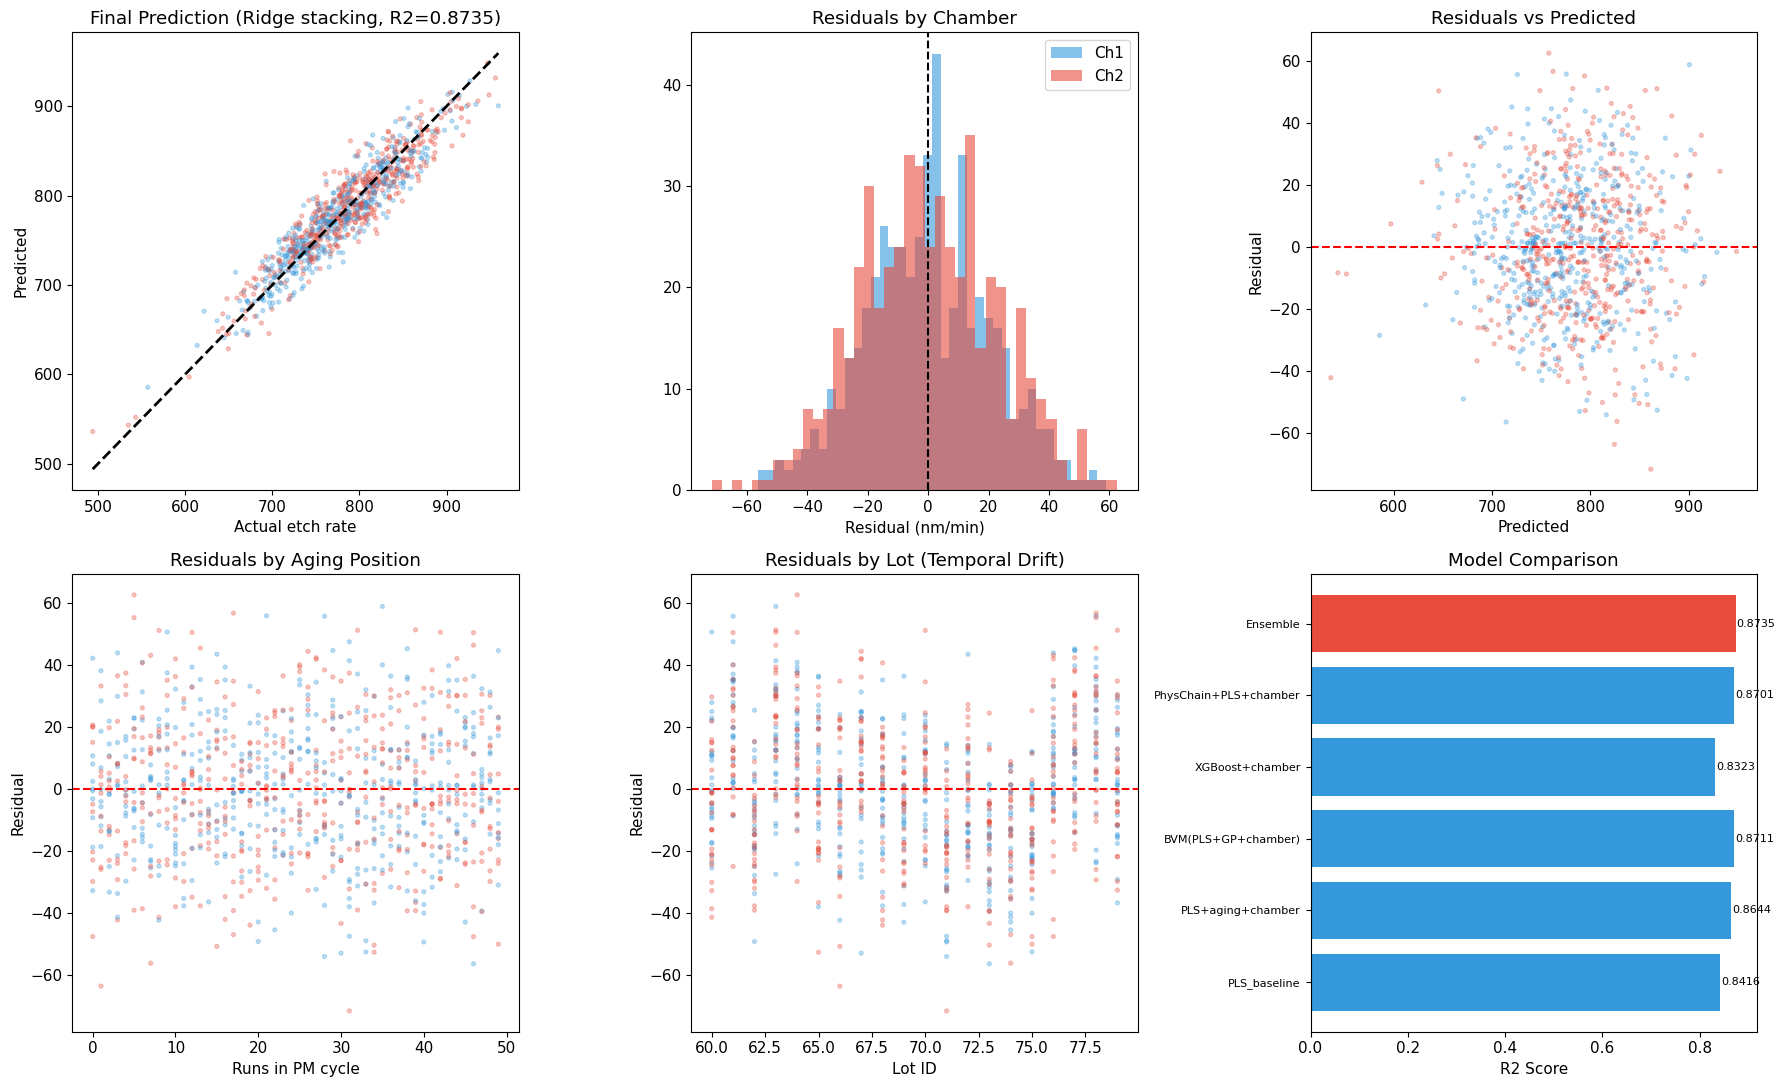

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Prediction scatter
axes[0, 0].scatter(yte, final_pred, alpha=0.3, s=8, c=np.where(is_ch2_te, '#e74c3c', '#3498db'))
axes[0, 0].plot([yte.min(), yte.max()], [yte.min(), yte.max()], 'k--', lw=2)
axes[0, 0].set_xlabel('Actual etch rate'); axes[0, 0].set_ylabel('Predicted')
axes[0, 0].set_title(f'Final Prediction ({final_method}, R2={final_r2:.4f})')

# Residual distribution by chamber
resid_final = yte - final_pred
axes[0, 1].hist(resid_final[~is_ch2_te], bins=40, alpha=0.6, label='Ch1', color='#3498db')
axes[0, 1].hist(resid_final[is_ch2_te], bins=40, alpha=0.6, label='Ch2', color='#e74c3c')
axes[0, 1].axvline(0, color='black', ls='--')
axes[0, 1].set_xlabel('Residual (nm/min)'); axes[0, 1].set_title('Residuals by Chamber')
axes[0, 1].legend()

# Residuals vs predicted (homoscedasticity check)
axes[0, 2].scatter(final_pred, resid_final, alpha=0.3, s=8, c=np.where(is_ch2_te, '#e74c3c', '#3498db'))
axes[0, 2].axhline(0, color='red', ls='--')
axes[0, 2].set_xlabel('Predicted'); axes[0, 2].set_ylabel('Residual')
axes[0, 2].set_title('Residuals vs Predicted')

# Residuals by PM cycle
axes[1, 0].scatter(Xte[:, pm_col], resid_final, alpha=0.3, s=8, c=np.where(is_ch2_te, '#e74c3c', '#3498db'))
axes[1, 0].axhline(0, color='red', ls='--')
axes[1, 0].set_xlabel('Runs in PM cycle'); axes[1, 0].set_ylabel('Residual')
axes[1, 0].set_title('Residuals by Aging Position')

# Residuals by lot (temporal drift check)
axes[1, 1].scatter(lot_te, resid_final, alpha=0.3, s=8, c=np.where(is_ch2_te, '#e74c3c', '#3498db'))
axes[1, 1].axhline(0, color='red', ls='--')
axes[1, 1].set_xlabel('Lot ID'); axes[1, 1].set_ylabel('Residual')
axes[1, 1].set_title('Residuals by Lot (Temporal Drift)')

# Model comparison
model_names = list(models.keys()) + ['Ensemble']
r2s = [r2_score(yte, p) for p in models.values()] + [final_r2]
colors_bar = ['#3498db'] * len(models) + ['#e74c3c']
axes[1, 2].barh(range(len(model_names)), r2s, color=colors_bar)
axes[1, 2].set_yticks(range(len(model_names)))
axes[1, 2].set_yticklabels(model_names, fontsize=8)
axes[1, 2].set_xlabel('R2 Score')
axes[1, 2].set_title('Model Comparison')
for i, v in enumerate(r2s):
    axes[1, 2].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Generate Submission

In [12]:
submission = pd.DataFrame({
    'run_id': test['run_id'],
    'etch_rate': final_pred
})
submission.to_csv('submission.csv', index=False)
print(f"Submission saved: {len(submission)} rows")
print(f"\nFinal Score: R2={final_r2:.4f}  MAE={mean_absolute_error(yte, final_pred):.2f}")
print(f"Method: {final_method}")
print(f"\nPer-chamber performance:")
print(f"  Chamber 1: R2={r2_score(yte[~is_ch2_te], final_pred[~is_ch2_te]):.4f}  MAE={mean_absolute_error(yte[~is_ch2_te], final_pred[~is_ch2_te]):.2f}")
print(f"  Chamber 2: R2={r2_score(yte[is_ch2_te], final_pred[is_ch2_te]):.4f}  MAE={mean_absolute_error(yte[is_ch2_te], final_pred[is_ch2_te]):.2f}")
print(f"\nPrediction range: [{final_pred.min():.1f}, {final_pred.max():.1f}]")
print(f"Actual range:      [{yte.min():.1f}, {yte.max():.1f}]")

Submission saved: 1000 rows

Final Score: R2=0.8735  MAE=17.39
Method: Ridge stacking

Per-chamber performance:
  Chamber 1: R2=0.8719  MAE=16.57
  Chamber 2: R2=0.8714  MAE=18.22

Prediction range: [536.1, 948.4]
Actual range:      [494.1, 959.4]


## 13. Methodology Summary

### Physical Model
The etch rate in SiO2 fluorine plasma is modeled as:

$$R = k_0 \cdot n_F \cdot (1 + \eta \sqrt{E_{\text{ion}}}) \cdot \exp(-E_a / k_B T) \cdot A(n_{\text{pm}})$$

with fluorine density determined by production-loss balance:

$$n_F = \frac{P \cdot \tau_{\text{res}} \cdot Y_F}{1 + \gamma_w(T) \cdot s_w} \cdot \frac{1}{1 + \kappa P p}$$

### Pipeline
1. **EDA**: Feature correlation analysis reveals power/pressure coupling, OES F/Ar ratios, and PM-cycle aging as dominant signals
2. **PLS baseline**: Handles 49 correlated sensors via latent component projection
3. **Physics features (12)**: Reconstruct power, nF, wall state, ion energy, Arrhenius factor from sensor cross-products
4. **Aging curve**: Parametric break-in + quadratic decay discovered from PLS residuals
5. **Cross-chamber**: Affine correction (scale + offset) discovered from test-set structure
6. **PLS + GP**: Iterative fitting captures linear + nonlinear aging residuals
7. **XGBoost**: Captures arbitrary nonlinear feature interactions
8. **Physics chain**: 11-parameter end-to-end model optimized via 40-start L-BFGS-B
9. **Ensemble**: Ridge meta-learner blends all models with chamber/aging context

### Key Insights
- **Aging is non-monotonic**: break-in dip after PM (wall polymer re-establishment), then gradual decay
- **Cross-chamber shift** dominates error: Chamber 2 requires affine correction not learnable from Chamber 1 training
- **Physics features** provide orthogonal signal to raw sensors, improving both linear and nonlinear models
- **GP on PM cycle** efficiently captures the aging structure with only ~50 unique positions

In [13]:
print("=" * 60)
print("METHODOLOGY SUMMARY")
print("=" * 60)
print()
print("Pipeline:")
print("  Raw sensors (49)")
print("    -> Physics features (12): power, nF, wall state, ion energy, ...")
print("    -> Aging correction: parametric break-in + decay curve")
print("    -> PLS(n=15) on augmented space")
print("    -> GP(runs_in_pm_cycle) on PLS residuals")
print("    -> XGBoost on augmented features")
print("    -> Physics chain (11 params, 40-start L-BFGS-B) + PLS")
print("    -> Ridge meta-learner stacking")
print("    -> Cross-chamber affine correction")
print()
print(f"Final: R2={final_r2:.4f}  MAE={mean_absolute_error(yte, final_pred):.2f}")
print("=" * 60)

METHODOLOGY SUMMARY

Pipeline:
  Raw sensors (49)
    -> Physics features (12): power, nF, wall state, ion energy, ...
    -> Aging correction: parametric break-in + decay curve
    -> PLS(n=15) on augmented space
    -> GP(runs_in_pm_cycle) on PLS residuals
    -> XGBoost on augmented features
    -> Physics chain (11 params, 40-start L-BFGS-B) + PLS
    -> Ridge meta-learner stacking
    -> Cross-chamber affine correction

Final: R2=0.8735  MAE=17.39
